# MITGCM Intermediate Parameters Processing for Temporal Scale Analysis

**Purpose**: Code for computing intermediate derived variables from the model diagnostics for the temporal scale analysis. These include: 

1. Computing conservative temperature, Absolute Salinity, and potential density
2. Rotating velocity vectors into along- and cross-shelf coordinates

**Luke Colosi | lcolosi@ucsd.edu**

Force matplotlib plots to display directly within the output cell of the notebook

In [1]:
%matplotlib inline

Import python libraries

In [2]:
import sys
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt 
from netCDF4 import Dataset, num2date
from datetime import datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import cmocean.cm as cmo
from scipy.interpolate import interp1d
import gsw
from pyproj import Proj, Transformer
from scipy.interpolate import PchipInterpolator, interp1d
from datetime import timedelta
import matplotlib as mpl
from matplotlib.lines import Line2D

# Set path to access python functions
ROOT = '/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/'
sys.path.append(ROOT + 'AirSeaCoupling/tools/')

#--- Other Functions ---# 
import cartopy_figs as cart
from process_cce_data import rotate_cce_vel

Set data analysis parameters

In [5]:
# Set processing parameters
option_proc          = 'vel' # Speicifies which processing will occur. Options include: 'vel' or 'density'

# Set time and space parameters  
lat_bnds     = [33, 35]                      # Specifies the latitude bounds for the region to analyze
lon_bnds     = [-123 % 360, -120 % 360]      # Specifies the longitude bounds for the region to analyze

# Set path to project directory
PATH = ROOT + 'AirSeaCoupling/data/mitgcm/SWOT_MARA_RUN4_LY/temporal/mooring_locations/'
PATH_bathy  = ROOT + 'AirSeaCoupling/data/bathymetry/'

Load mitgcm data netcdf files 

In [6]:
#------------------------------------------# 
# Velocity Processing
#------------------------------------------# 
if option_proc == 'vel':

    # Obtain filename paths
    filename_u = PATH + "UVEL_CCS4_hrly_ts_profile.nc"
    filename_v = PATH + "VVEL_CCS4_hrly_ts_profile.nc"

    # Generate the nc data structure
    nc_u = Dataset(filename_u, 'r')
    nc_v = Dataset(filename_v, 'r')

    # Extract data variables
    site   = nc_u['site'][:]
    depth  = nc_u.variables['Z'][:]
    lon    = nc_u.variables['XC'][:]
    lat    = nc_u.variables['YC'][:]
    time   =  num2date(nc_u.variables['time'][:], nc_u.variables['time'].units)

    u_raw  = nc_u.variables['UVEL'][:]
    v_raw  = nc_v.variables['VVEL'][:]

    # Mask data at fill values (zero for the MITgcm output)
    u_m = np.ma.masked_where(u_raw == 0, u_raw)
    v_m = np.ma.masked_where(v_raw == 0, v_raw)

#------------------------------------------# 
# Density Processing
#------------------------------------------# 
elif option_proc == 'density':

    # Obtain filename paths
    filename_temp = PATH + "THETA_CCS4_hrly_ts_profile.nc"
    filename_salt = PATH + "SALT_CCS4_hrly_ts_profile.nc"
    filename_drhodr = PATH + "DRHODR_CCS4_hrly_ts_profile.nc"

    # Generate the nc data structure
    nc_temp = Dataset(filename_temp, 'r')
    nc_salt = Dataset(filename_salt, 'r')
    nc_drhodr = Dataset(filename_drhodr, 'r')

    # Extract data variables
    site = nc_temp['site'][:]
    depth = nc_temp['Z'][:]
    lon = nc_temp.variables['XC'][:]
    lat = nc_temp.variables['YC'][:]
    time =  num2date(nc_temp.variables['time'][:], nc_temp.variables['time'].units)

    T = nc_temp.variables['THETA'][:]
    S = nc_salt.variables['SALT'][:]
    drho = nc_drhodr.variables['DRHODR'][:]

    # Mask data at fill values (zero for the MITgcm output)
    T_m = np.ma.masked_where(T == 0, T)
    S_m = np.ma.masked_where(S == 0, S)
    drho_m = np.ma.masked_where(drho == 0, drho)

# Convert cftime.DatetimeGregorian to Python datetime objects
time_dt = np.array([datetime(d.year, d.month, d.day, d.hour, d.minute, d.second) for d in time])

## Section 1: **Processing horizontal velocity**

Read in bathymetry data

In [5]:
if option_proc == 'vel':
    
    # Load bathymetry data 
    filename = PATH_bathy + "topo_25.1.nc"
    ds_bathy = xr.open_dataset(filename, engine="netcdf4")

    # Extract data variables
    lon_b = ds_bathy["lon"]  # Longitude
    lat_b = ds_bathy["lat"]  # Latitude
    bathy = ds_bathy["z"]    # Elevation/Bathymetry

    # Convert convesion of longitude (neg from the prime meridian to positive definite wrapping around the earth)
    lon_n = lon_b % 360

    # Set max and min values 
    lon_min = lon_bnds[0]
    lon_max = lon_bnds[1]
    lat_min = lat_bnds[0]
    lat_max = lat_bnds[1]

    # Extract data from bathymetry 
    lon_grid = lon_n[(lon_n >= lon_min) & (lon_n <= lon_max)]
    lat_grid = lat_b[(lat_b >= lat_min) & (lat_b <= lat_max)]
    bathy_grid   = bathy[(lat_b >= lat_min) & (lat_b <= lat_max),(lon_n >= lon_min) & (lon_n <= lon_max)]

Rotate velocity vectors at each CCE site

In [6]:
if option_proc == 'vel':

    # Set parameters for rotating vectors
    option_plot = 0       # Specifies whether to plot the verification plots
    option_mask = 1       # Specifies whether there is a depth mask applied
    depth_thresh = 600    # Specify the lower depth limit of depth average if option_mask is true. 

    #--- CCE 1 ---# 

    # Set parameters
    idx_site = 0
    isobath = -200
    x_bnds = [-23, 19]  
    y_bnds = [-22,  20]     

    # Rotate the velocity vectors
    u_bar1, v_bar1, \
    u_bar1_bin, v_bar1_bin, \
    u_along1, v_cross1, \
    u_along1_bin, v_cross1_bin, \
    u_along_bar1, v_cross_bar1, \
    u_along_bar1_bin, v_cross_bar1_bin, \
    theta1, time_bin_dt = rotate_cce_vel(u_m, v_m, time, depth, bathy_grid, lon_grid, lat_grid,
                            option_plot, isobath, x_bnds, y_bnds, idx_site, option_mask,
                            depth_thresh)

    #--- CCE 2 ---# 

    # Set parameters
    idx_site = 1
    isobath = -2000 
    x_bnds = [-100, 100]  
    y_bnds = [-200,  200] 

    # Rotate the veloity vectors
    u_bar2, v_bar2, \
    u_bar2_bin, v_bar2_bin, \
    u_along2, v_cross2, \
    u_along2_bin, v_cross2_bin, \
    u_along_bar2, v_cross_bar2, \
    u_along_bar2_bin, v_cross_bar2_bin, \
    theta2, _ = rotate_cce_vel(u_m, v_m, time, depth, bathy_grid, lon_grid, lat_grid,
                            option_plot, isobath, x_bnds, y_bnds, idx_site, option_mask,
                            depth_thresh)


    #--- CCE 3 ---# 

    # Set parameters
    idx_site = 2
    isobath = -2000
    x_bnds = [-100, 100]  
    y_bnds = [-200,  200] 

    # Rotate the veloity vectors
    u_bar3, v_bar3, \
    u_bar3_bin, v_bar3_bin, \
    u_along3, v_cross3, \
    u_along3_bin, v_cross3_bin, \
    u_along_bar3, v_cross_bar3, \
    u_along_bar3_bin, v_cross_bar3_bin, \
    theta3, _ = rotate_cce_vel(u_m, v_m, time, depth, bathy_grid, lon_grid, lat_grid,
                            option_plot, isobath, x_bnds, y_bnds, idx_site, option_mask,
                            depth_thresh)


    # Combine variables
    u_bar       = np.stack([u_bar1, u_bar2, u_bar3], axis=0) 
    v_bar       = np.stack([v_bar1, v_bar2, v_bar3], axis=0) 
    u_bar_bin   = np.stack([u_bar1_bin, u_bar2_bin, u_bar3_bin], axis=0) 
    v_bar_bin   = np.stack([v_bar1_bin, v_bar2_bin, v_bar3_bin], axis=0) 
    u_along     = np.stack([u_along1, u_along2, u_along3], axis=0)
    v_cross     = np.stack([v_cross1, v_cross2, v_cross3], axis=0)
    u_along_bin     = np.stack([u_along1_bin, u_along2_bin, u_along3_bin], axis=0)
    v_cross_bin     = np.stack([v_cross1_bin, v_cross2_bin, v_cross3_bin], axis=0)
    u_along_bar = np.stack([u_along_bar1, u_along_bar2, u_along_bar3], axis=0) 
    v_cross_bar = np.stack([v_cross_bar1, v_cross_bar2, v_cross_bar3], axis=0) 
    u_along_bar_bin = np.stack([u_along_bar1_bin, u_along_bar2_bin, u_along_bar3_bin], axis=0) 
    v_cross_bar_bin = np.stack([v_cross_bar1_bin, v_cross_bar2_bin, v_cross_bar3_bin], axis=0) 
    theta       = np.array([theta1, theta2, theta3])

    # Mask zeros
    u_along = np.ma.masked_where(u_along == 0, u_along)
    v_cross = np.ma.masked_where(v_cross == 0, v_cross)
    u_along_bin = np.ma.masked_where(u_along_bin == 0, u_along_bin)
    v_cross_bin = np.ma.masked_where(v_cross_bin == 0, v_cross_bin)

## Section 2: **Processing Conservative Temperature, Absolute Salinity, and Potential Density** 

In [7]:
if option_proc == 'density': 

    # Set the dimensions of the array
    nsite, ntime, ndepth = T_m.shape

    # Compute pressure once for each site and depth, since pressure is independent of time
    pressure_site_depth = np.array([gsw.p_from_z(depth, lat[i]) for i in range(nsite)])  # Shape: (nsite, ndepth)

    # Broadcast pressure, lon, and lat to shape of full array
    pressure = np.broadcast_to(pressure_site_depth[:, None, :], (nsite, ntime, ndepth))
    lon3d = np.broadcast_to(lon[:, None, None], (nsite, ntime, ndepth))
    lat3d = np.broadcast_to(lat[:, None, None], (nsite, ntime, ndepth))

    # Compute Absolute Salinity
    SA = gsw.SA_from_SP(S_m, pressure, lon3d, lat3d)

    # Compute Conservative Temperature
    CT = gsw.CT_from_pt(SA, T_m)

    # Compute in-situ density
    density = gsw.rho(SA, CT, pressure)

    # Compute potential density anomaly (sigma0)
    sigma0 = gsw.sigma0(SA, CT)

Compute the buoyancy frequency using drhodr and the Chelton formulation from estimates of the density. The Chelton et al. 1998 formulation is defined as: 

$$
N^2(z_{k +1/2}) = - \frac{g}{\rho_o} \bigg[\frac{\rho(z_k \rightarrow z_{k+1/2}) - \rho(z_{k+1} \rightarrow z_{k+1/2})}{z_k - z_{k+1}} \bigg]
$$

In [15]:
if option_proc == 'density': 

    ##############################
    #--- Compute Buoyancy Frequency N^2 using the Neutral Density Gradient Method method ---#
    ##############################
    
    # Set physical parameters 
    g = 9.81  # Units: m/s^2
    rho_theta = sigma0 + 1000
    nsite, ntime, ndepth = np.shape(sigma0)

    # Compute the mean density in the upper 500 m for reference density
    rho0 = np.ma.mean(rho_theta[:,:,(depth <= depth[0]) & (depth >= -500)])

    # Initalize arrays 
    depth_mid = np.zeros((ndepth-1))
    Nsquare = np.zeros((nsite,ntime,ndepth-1))

    # Loop through CCE sites 
    for isite in range(0,nsite):

        # Loop through time steps
        for itime in range(0,ntime):

            # Loop through depth pairs 
            for k in range(0,len(depth)-1):

                # Compute the midpoint standard depth 
                z_half = (depth[k] + depth[k+1]) / 2

                # Convert standard depth to a reference pressure 
                p_half = gsw.conversions.z_from_p(z_half,lat[isite])

                # Compute the potential density referenced to p_half pressure
                sigma_ref_top  = gsw.pot_rho_t_exact(SA[isite,itime,k], T_m[isite,itime,k], pressure[isite,itime,k], p_half)
                sigma_ref_bottom  = gsw.pot_rho_t_exact(SA[isite,itime,k], T_m[isite,itime,k], pressure[isite,itime,k], p_half)

                # Compute N^2(z) profile 
                Nsquare[isite,itime,k] = (-g/rho0) * ((sigma_ref_top - sigma_ref_bottom)/(depth[k] - depth[k+1]))

                # Save the midpoints of the depth bins 
                if (itime == 0) & (isite == 0):
                    depth_mid[k] = z_half

    # Compute bouyancy frequency in units of cycles/hour
    Nz = np.sqrt(Nsquare) * (60/1) * (60/1) 

/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_98948/3019394345.py:39: UserWarning: Warning: converting a masked element to nan.
  Nsquare[isite,itime,k] = (-g/rho0) * ((sigma_ref_top - sigma_ref_bottom)/(depth[k] - depth[k+1]))


Plot the potential density for each mooring

/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_98948/3158868742.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


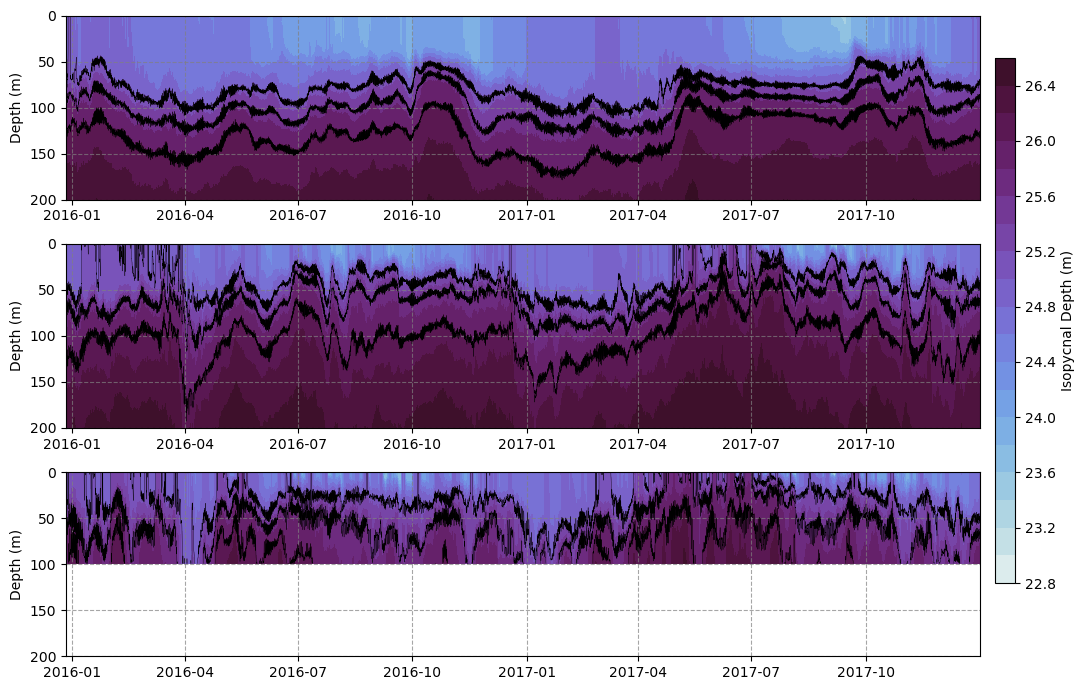

In [16]:
if option_proc == 'density': 

    # Target sigma grid
    levels = np.arange(25, 26 + 0.5, 0.5)

    # Create figure
    fig, axes = plt.subplots(3,1,figsize=(10,7))

    #--- Subplot 1 ---# 
    ax = axes[0]

    # Plot potential density
    cf = ax.contourf(time_dt,abs(depth),sigma0[0,:,:].T, levels=20, vmin=22.8, vmax=26.6, cmap=cmo.dense)
    ax.contour(time_dt,abs(depth),sigma0[0,:,:].T, levels=levels, vmin=22.8, vmax=26.6,colors='k',linewidths=0.25)

    # Set axis attributes
    ax.set_ylabel('Depth (m)')
    ax.set_ylim(0,200)
    ax.invert_yaxis()
    ax.grid(linestyle='--',alpha=0.7,color='grey')

    #--- Subplot 2 ---# 
    ax = axes[1]

    # Plot potential density
    cf = ax.contourf(time_dt,abs(depth),sigma0[1,:,:].T, levels=20,vmin=22.8, vmax=26.6, cmap=cmo.dense)
    ax.contour(time_dt,abs(depth),sigma0[1,:,:].T, levels=levels, vmin=22.8, vmax=26.6,colors='k',linewidths=0.25)

    # Set axis attributes
    ax.set_ylabel('Depth (m)')
    ax.set_ylim(0,200)
    ax.invert_yaxis()
    ax.grid(linestyle='--',alpha=0.7,color='grey')

    #--- Subplot 2 ---# 
    ax = axes[2]

    # Plot potential density
    cf = ax.contourf(time_dt,abs(depth),sigma0[2,:,:].T, levels=20, vmin=22.8, vmax=26.6, cmap=cmo.dense)
    ax.contour(time_dt,abs(depth),sigma0[2,:,:].T, levels=levels, vmin=22.8, vmax=26.6,colors='k',linewidths=0.25)

    # Set axis attributes
    ax.set_ylabel('Depth (m)')
    ax.set_ylim(0,200)
    ax.invert_yaxis()
    ax.grid(linestyle='--',alpha=0.7,color='grey')

    # Set colorbar
    cax = fig.add_axes([1, 0.16, 0.02, 0.75])# [left, bottom, width, height]
    cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both')
    cbar.set_label(r'Isopycnal Depth (m)')

    # Display 
    plt.tight_layout()
    plt.show()

Transform conservative temperature, absolute salinity, and potential density at the surface to isopycnal surfaces

In [17]:
if option_proc == 'density': 

    # Slice temperature, salinity, and density so we are only looking at the top 200 meters
    idx_depth    = depth >= -200
    CT_upper     = CT[:,:,idx_depth]
    SA_upper     = SA[:,:,idx_depth]
    sigma0_upper = sigma0[:,:,idx_depth]
    depth_upper  = depth[idx_depth]

    # Target sigma grid
    sigma_lims = [
        np.floor(sigma0_upper.min() * 10**1) / 10**1,
        np.floor(sigma0_upper.max() * 10**1) / 10**1,
    ]
    sigma_levels = np.arange(sigma_lims[0], sigma_lims[1] + 0.1, 0.1)

    # Allocate output arrays
    ncce = CT_upper.shape[0]
    ntime = CT_upper.shape[1]
    nsigma = len(sigma_levels)

    z_on_sigma = np.full((ncce, ntime, nsigma), np.nan)
    T_on_sigma = np.full((ncce, ntime, nsigma), np.nan)
    S_on_sigma = np.full((ncce, ntime, nsigma), np.nan)

    # Quality control flag (1 = overturn detected, 0 = stable)
    overturn_flag = np.zeros((ncce, ntime), dtype=int)

    # Option for interpolation: 0 = linear, 1 = Pchip
    option_interp = 1  # change this as needed

    # Threshold for significant overturn (adjustable)
    rmsd_thresh = 1e-3  # in sigma units, e.g. 0.001 kg/m^3

    # Loop through sites
    for isite in range(ncce): 

        # Loop over time
        for it in range(ntime):

            # Extract profiles and mask bad values
            sigma_prof = sigma0_upper[isite,it,:]
            temp_prof  = CT_upper[isite,it,:]
            sal_prof   = SA_upper[isite,it,:]
            depth_prof = depth_upper

            # Build a valid mask (common to all variables)
            valid_mask = ~(sigma_prof.mask | temp_prof.mask | sal_prof.mask)

            if valid_mask.sum() < 3:
                # Not enough valid points to interpolate
                continue

            # Apply mask
            sigma_prof = sigma_prof[valid_mask]
            temp_prof  = temp_prof[valid_mask]
            sal_prof   = sal_prof[valid_mask]
            depth_prof = depth_prof[valid_mask]

            # --- Sort profiles by density to remove overturning --- #
            sort_idx = np.argsort(sigma_prof)
            sigma_sorted = sigma_prof[sort_idx]
            temp_sorted  = temp_prof[sort_idx]
            sal_sorted   = sal_prof[sort_idx]
            depth_sorted = depth_prof[sort_idx]

            # --- Quality-control check for overturning --- #
            rmsd = np.sqrt(np.nanmean((sigma_prof - sigma_sorted)**2))
            if rmsd > rmsd_thresh:
                overturn_flag[isite,it] = 1  # mark as containing overturns

            # --- Choose interpolation method --- # 
            if option_interp == 1:  # Pchip interpolation
                z_interp = PchipInterpolator(sigma_sorted, depth_sorted, extrapolate=False)
                T_interp = PchipInterpolator(sigma_sorted, temp_sorted, extrapolate=False)
                S_interp = PchipInterpolator(sigma_sorted, sal_sorted, extrapolate=False)
            else:  # Linear interpolation
                z_interp = interp1d(sigma_sorted, depth_sorted, bounds_error=False, fill_value=np.nan)
                T_interp = interp1d(sigma_sorted, temp_sorted, bounds_error=False, fill_value=np.nan)
                S_interp = interp1d(sigma_sorted, sal_sorted, bounds_error=False, fill_value=np.nan)

            # Evaluate at sigma levels
            z_on_sigma[isite,it,:] = np.ma.masked_invalid(z_interp(sigma_levels))
            T_on_sigma[isite,it,:] = np.ma.masked_invalid(T_interp(sigma_levels))
            S_on_sigma[isite,it,:] = np.ma.masked_invalid(S_interp(sigma_levels))

Plot each variable in isopycnal coordinates 

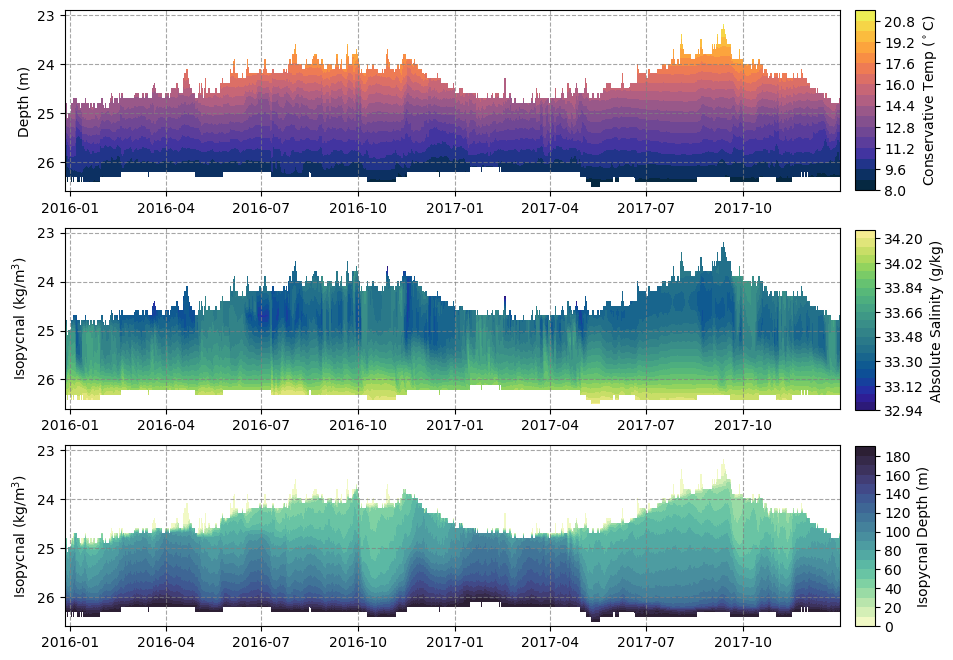

In [ ]:
if option_proc == 'density': 
    
    # Set plotting parameters
    option_cce = 0

    # Create figure
    fig, axes = plt.subplots(3,1,figsize=(10,8))

    #--- Subplot 1 ---# 
    ax = axes[0]

    # Plot temperature vs. isopycnal depth
    cf = ax.contourf(time_dt,sigma_levels,T_on_sigma[option_cce,:,:].T,levels=20, cmap=cmo.thermal)

    # Set axis attributes
    ax.set_ylabel('Isopycnal (kg/m$^3$)')
    ax.invert_yaxis()
    ax.grid(linestyle='--',alpha=0.7,color='grey')

    # Set colorbar
    cax = fig.add_axes([0.915, 0.655, 0.02, 0.225])# [left, bottom, width, height]
    cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both')
    cbar.set_label(r'Conservative Temp ($^\circ$C)')


    #--- Subplot 1 ---# 
    ax = axes[1]

    # Plot salinity vs. isopycnal depth
    cf = ax.contourf(time_dt,sigma_levels,S_on_sigma[option_cce,:,:].T,levels=20, cmap=cmo.haline)

    # Set axis attributes
    ax.set_ylabel('Isopycnal (kg/m$^3$)')
    ax.invert_yaxis()
    ax.grid(linestyle='--',alpha=0.7,color='grey')

    # Set colorbar
    cax = fig.add_axes([0.915, 0.38, 0.02, 0.225])# [left, bottom, width, height]
    cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both')
    cbar.set_label(r'Absolute Salinity (g/kg)')

    #--- Subplot 3 ---# 
    ax = axes[2]

    # Plot salinity vs. isopycnal depth
    cf = ax.contourf(time_dt,sigma_levels,abs(z_on_sigma[option_cce,:,:]).T,levels=20, cmap=cmo.deep)

    # Set axis attributes
    ax.set_ylabel('Isopycnal (kg/m$^3$)')
    ax.invert_yaxis()
    ax.grid(linestyle='--',alpha=0.7,color='grey')

    # Set colorbar
    cax = fig.add_axes([0.915, 0.11, 0.02, 0.225])# [left, bottom, width, height]
    cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both')
    cbar.set_label(r'Isopycnal Depth (m)')


Check for near-continuous gaps and grab data 

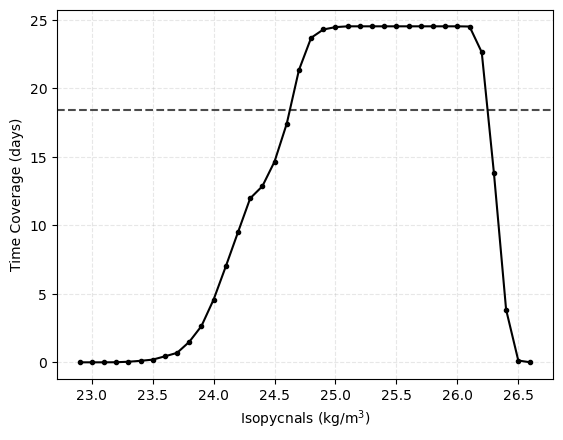

Continuous sigma range: 24.700000000000024 - 26.200000000000045


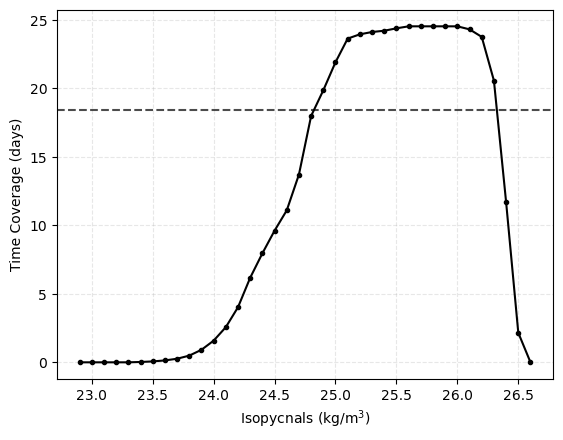

Continuous sigma range: 24.900000000000027 - 26.300000000000047


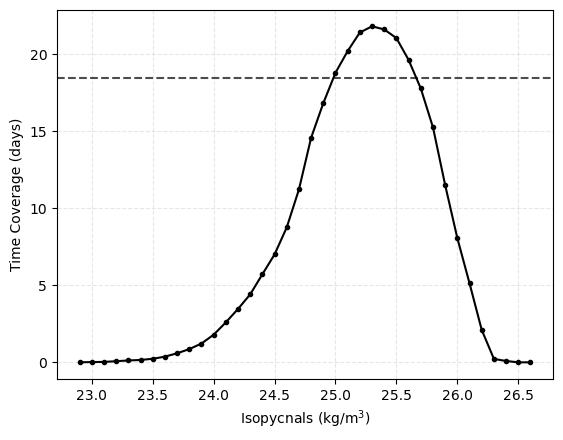

Continuous sigma range: 25.00000000000003 - 25.600000000000037


In [19]:
if option_proc == 'density': 

    # Set threshold for continuity
    threshold_frac = 0.75  # 95% continuity required
    ntime = z_on_sigma.shape[1]

    # Mask nans
    z_on_sigma = np.ma.masked_invalid(z_on_sigma)
    T_on_sigma = np.ma.masked_invalid(T_on_sigma)
    S_on_sigma = np.ma.masked_invalid(S_on_sigma)

    # Initialize array
    z_on_sigma_cont = []
    T_on_sigma_cont = []
    S_on_sigma_cont = []
    isopycnal       = []

    # Loop through cce moorings
    for im in range(ncce): 

        # Count valid points along time for each sigma level
        valid_counts = np.sum(~z_on_sigma.mask[im,:,:], axis=0)

        # Display valid counts threshold
        fig, ax = plt.subplots()
        ax.plot(sigma_levels,valid_counts/(24*30),'k.-')
        ax.axhline(threshold_frac * ntime / (24*30),color='k', linestyle='--', alpha= 0.7)
        ax.set_xlabel('Isopycnals (kg/m$^{3}$)')
        ax.set_ylabel('Time Coverage (days)')
        ax.grid(linestyle='--', alpha=0.3)
        plt.show()  

        # Find sigma levels that meet threshold
        valid_levels_idx = np.where(valid_counts >= threshold_frac * ntime)[0]

        # Set limits of continuous region and print limits
        if valid_levels_idx.size > 0:
            sigma_min = sigma_levels[valid_levels_idx[0]]
            sigma_max = sigma_levels[valid_levels_idx[-1]]
            print("Continuous sigma range:", sigma_min, "-", sigma_max)
        else:
            print("No sigma level meets continuity threshold")

        # Find the indices of sigma_levels within the continuous range
        sigma_idx = np.where((sigma_levels >= sigma_min) & (sigma_levels <= sigma_max))[0]

        # Slice T_on_sigma, z_on_sigma and S_on_sigma to keep only the continuous σ-levels
        T_on_sigma_cont.append(T_on_sigma[im,:,sigma_idx])
        z_on_sigma_cont.append(z_on_sigma[im,:,sigma_idx])
        S_on_sigma_cont.append(S_on_sigma[im,:,sigma_idx])

        # Set the isopycnals levels 
        isopycnal.append(sigma_levels[sigma_idx])

Save intermediate data in a netCDF for future use

In [20]:
# Save variables in data arrays

if option_proc == 'density': 

    #--- Mooring Positions ---# 
    LON = xr.DataArray(data=lon, 
                        dims=['site'],
                        coords=dict(site=site),
                        attrs=dict(
                            description='Longitude for the three CCE mooring sites.',
                            units='degrees'
                            )
    )

    LAT = xr.DataArray(data=lat, 
                        dims=['site'],
                        coords=dict(site=site),
                        attrs=dict(
                            description='Latitude for the three CCE mooring sites.',
                            units='degrees'
                            )
    )

    #--- Sea State Varibles ---# 
    Pressure = xr.DataArray(data=pressure, 
                        dims=['site','time','depth'],
                        coords=dict(site=site,time=time_dt,depth=depth),
                        attrs=dict(
                            description='Pressure profile time series for the three CCE mooring sites.',
                            units='dbar'
                            )
    )

    Density = xr.DataArray(data=density, 
                        dims=['site','time','depth'],
                        coords=dict(site=site,time=time_dt,depth=depth),
                        attrs=dict(
                            description='In-situ Density profile time series for the three CCE mooring sites.',
                            units='kg/m^3'
                            )
    ) 

    SIG = xr.DataArray(data=sigma0, 
                        dims=['site','time','depth'],
                        coords=dict(site=site,time=time_dt,depth=depth),
                        attrs=dict(
                            description='Potential Density anomaly profile time series for the three CCE mooring sites referenced to the pressure at the sea surface.',
                            units='kg/m^3'
                            )
    ) 

    CTemp = xr.DataArray(data=CT, 
                        dims=['site','time','depth'],
                        coords=dict(site=site,time=time_dt,depth=depth),
                        attrs=dict(
                            description='Conservative temperature profile time series for the three CCE mooring sites.',
                            units='degrees Celcius'
                            )
    ) 

    ASal = xr.DataArray(data=SA, 
                        dims=['site','time','depth'],
                        coords=dict(site=site,time=time_dt,depth=depth),
                        attrs=dict(
                            description='Absolute Salinity profile time series for the three CCE mooring sites.',
                            units='g/kg'
                            )
    )

    Nz = xr.DataArray(data=Nz, 
                      dims=['site','time','depth_mid'],
                      coords=dict(site=site,time=time_dt,depth_mid=depth_mid),
                      attrs=dict(
                            description='Buoyancy Frequency profile time series for the three CCE mooring sites.',
                            units='cycles/hour'
                            )
    )

    CTemp1_sig = xr.DataArray(data=T_on_sigma_cont[0], 
                        dims=['isopycnal1','time',],
                        coords=dict(isopycnal1=isopycnal[0],time=time_dt),
                        attrs=dict(
                            description='Conservative Temperature profiles time series in isopycnal coordinates for CCE 1 with ' + str(threshold_frac*100) + ' percent of the time series containing data.',
                            units='deg C'
                            )
    ) 

    CTemp2_sig = xr.DataArray(data=T_on_sigma_cont[1], 
                        dims=['isopycnal2','time',],
                        coords=dict(isopycnal2=isopycnal[1],time=time_dt),
                        attrs=dict(
                            description='Conservative Temperature profiles time series in isopycnal coordinates for CCE 2 with ' + str(threshold_frac*100) + ' percent of the time series containing data.',
                            units='deg C'
                            )
    ) 

    CTemp3_sig = xr.DataArray(data=T_on_sigma_cont[2], 
                        dims=['isopycnal3','time',],
                        coords=dict(isopycnal3=isopycnal[2],time=time_dt),
                        attrs=dict(
                            description='Conservative Temperature profiles time series in isopycnal coordinates for CCE 3 with ' + str(threshold_frac*100) + ' percent of the time series containing data.',
                            units='deg C'
                            )
    ) 

    ASal1_sig = xr.DataArray(data=S_on_sigma_cont[0], 
                        dims=['isopycnal1','time',],
                        coords=dict(isopycnal1=isopycnal[0],time=time_dt),
                        attrs=dict(
                            description='Absolute Salinity profiles time series in isopycnal coordinates for CCE 1 with ' + str(threshold_frac*100) + ' percent of the time series containing data.',
                            units='g/kg'
                            )
    ) 

    ASal2_sig = xr.DataArray(data=S_on_sigma_cont[1], 
                        dims=['isopycnal2','time',],
                        coords=dict(isopycnal2=isopycnal[1],time=time_dt),
                        attrs=dict(
                            description='Absolute Salinity profiles time series in isopycnal coordinates for CCE 2 with ' + str(threshold_frac*100) + ' percent of the time series containing data.',
                            units='g/kg'
                            )
    )

    ASal3_sig = xr.DataArray(data=S_on_sigma_cont[2], 
                        dims=['isopycnal3','time',],
                        coords=dict(isopycnal3=isopycnal[2],time=time_dt),
                        attrs=dict(
                            description='Absolute Salinity profiles time series in isopycnal coordinates for CCE 3 with ' + str(threshold_frac*100) + ' percent of the time series containing data.',
                            units='g/kg'
                            )
    )

    Z1_sig = xr.DataArray(data=z_on_sigma_cont[0], 
                        dims=['isopycnal1','time',],
                        coords=dict(isopycnal1=isopycnal[0],time=time_dt),
                        attrs=dict(
                            description='Isopycnal depth profiles time series in isopycnal coordinates for CCE 1 with ' + str(threshold_frac*100) + ' percent of the time series containing data.',
                            units='m'
                            )
    ) 

    Z2_sig = xr.DataArray(data=z_on_sigma_cont[1], 
                            dims=['isopycnal2','time',],
                            coords=dict(isopycnal2=isopycnal[1],time=time_dt),
                            attrs=dict(
                                description='Isopycnal depth profiles time series in isopycnal coordinates for CCE 2 with ' + str(threshold_frac*100) + ' percent of the time series containing data.',
                                units='m'
                                )
        )
    
    Z3_sig = xr.DataArray(data=z_on_sigma_cont[2], 
                            dims=['isopycnal3','time',],
                            coords=dict(isopycnal3=isopycnal[2],time=time_dt),
                            attrs=dict(
                                description='Isopycnal depth profiles time series in isopycnal coordinates for CCE 3 with ' + str(threshold_frac*100) + ' percent of the time series containing data.',
                                units='m'
                                )
        )

if option_proc == 'vel': 

    #--- Mooring Positions ---# 
    LON = xr.DataArray(data=lon, 
                        dims=['site'],
                        coords=dict(site=site),
                        attrs=dict(
                            description='Longitude for the three CCE mooring sites.',
                            units='degrees'
                            )
    )

    LAT = xr.DataArray(data=lat, 
                        dims=['site'],
                        coords=dict(site=site),
                        attrs=dict(
                            description='Latitude for the three CCE mooring sites.',
                            units='degrees'
                            )
    )

    #--- Depth-dependent Velocity Components ---#
    u = xr.DataArray(data=u_m,
                        dims=['site','time','depth'],
                        coords=dict(site=site,time=time_dt,depth=depth),
                        attrs=dict(
                            description='The x-component (zonal) of velocity.',
                            units='m/s'
                        )
    )

    v = xr.DataArray(data=v_m,
                        dims=['site','time','depth'],
                        coords=dict(site=site,time=time_dt,depth=depth),
                        attrs=dict(
                            description='The y-component (meridional) of velocity.',
                            units='m/s'
                        )
    )

    u_along = xr.DataArray(data=u_along,
                        dims=['site','time','depth'],
                        coords=dict(site=site,time=time_dt,depth=depth),
                        attrs=dict(
                            description='The along-shelf component of velocity with upcoast being in the postive direction.',
                            units='m/s'
                        )
    )

    v_cross = xr.DataArray(data=v_cross,
                        dims=['site','time','depth'],
                        coords=dict(site=site,time=time_dt,depth=depth),
                        attrs=dict(
                            description='The cross-shelf component of velocity with offshore being in the postive direction.',
                            units='m/s'
                        )
    )

    u_along_bin = xr.DataArray(data=u_along_bin,
                        dims=['site','time_bin','depth'],
                        coords=dict(site=site,time_bin=time_bin_dt,depth=depth),
                        attrs=dict(
                            description='The along-shelf component of velocity with upcoast being in the postive direction. Bin averaged to 12 hourly resolution.',
                            units='m/s'
                        )
    )

    v_cross_bin = xr.DataArray(data=v_cross_bin,
                        dims=['site','time_bin','depth'],
                        coords=dict(site=site,time_bin=time_bin_dt,depth=depth),
                        attrs=dict(
                            description='The cross-shelf component of velocity with offshore being in the postive direction. Bin averaged to 12 hourly resolution.',
                            units='m/s'
                        )
    )
    

    #--- Depth-averaged Velocity Components ---#
    u_bar = xr.DataArray(data=u_bar,
                        dims=['site','time'],
                        coords=dict(site=site,time=time_dt),
                        attrs=dict(
                            description='The depth averaged x-component (zonal) of velocity  to ' + str(depth_thresh) + ' meters.',
                            units='m/s'
                        )
    )

    v_bar = xr.DataArray(data=v_bar,
                        dims=['site','time'],
                        coords=dict(site=site,time=time_dt),
                        attrs=dict(
                            description='The depth averaged y-component (meridional) of velocity  to ' + str(depth_thresh) + ' meters.',
                            units='m/s'
                    )
    )

    u_along_bar = xr.DataArray(data=u_along_bar,
                        dims=['site','time'],
                        coords=dict(site=site,time=time_dt),
                        attrs=dict(
                            description='The depth averaged (integrated to ' + str(depth_thresh) + ' meters) along-shelf component of velocity with upcoast being in the postive direction.',
                            units='m/s'
                        )
    )

    v_cross_bar = xr.DataArray(data=v_cross_bar,
                        dims=['site','time'],
                        coords=dict(site=site,time=time_dt),
                        attrs=dict(
                            description='The depth averaged (integrated to ' + str(depth_thresh) + ' meters) cross-shelf component of velocity with offshore being in the postive direction.',
                            units='m/s'
                    )
    )

# Create a data set from data arrays 
if option_proc == 'vel':  

    data = xr.Dataset({'LON':LON,'LAT':LAT,'u':u,'v':v,'u_along':u_along,'v_cross':v_cross, 'u_along_bin': u_along_bin, 'v_cross_bin':v_cross_bin,'u_bar':u_bar,'v_bar':v_bar,'u_along_bar':u_along_bar,'v_cross_bar':v_cross_bar})
    file_path = PATH + "/mitgcm_intermediate_data_vel_hrly_ts_profiles.nc"

if option_proc == 'density':  

    data = xr.Dataset({'LON':LON,'LAT':LAT,'Pressure':Pressure,'Density':Density,'SIG':SIG,'CTemp':CTemp,'ASal':ASal, 'CTemp1_sig':CTemp1_sig, 'CTemp2_sig':CTemp2_sig, 'CTemp3_sig':CTemp3_sig, 'ASal1_sig':ASal1_sig, 'ASal2_sig':ASal2_sig, 'ASal3_sig':ASal3_sig, 'Z1_sig':Z1_sig, 'Z2_sig':Z2_sig, 'Z3_sig':Z3_sig})
    file_path = PATH + "/mitgcm_intermediate_data_TSD_hrly_ts_profiles.nc"

# Check if file exists, then delete it
if os.path.exists(file_path):
    os.remove(file_path)

# Create netcdf file
data.to_netcdf(file_path,mode='w')